# News Text Classification Case Study

**Author:** [Nikos Mavrapidis](https://github.com/NikosMav)
**Year:** 2023 (cleaned up for a reproducible local run)

Binary supervised classification of news articles into **true** vs **fake** labels using classical NLP vectorization and standard classifiers:

- Vectorizers: Bag-of-Words (Count), TF-IDF, averaged Word2Vec
- Models: Logistic Regression, Multinomial Naive Bayes, linear SVM, Random Forest

This notebook is a **classification / NLP case study**, not a production fake-news product, and not a retrieval or RAG system. See the closing section for an honest boundary between this work and retrieval engineering.

## Setup

Requires `True.csv` and `Fake.csv` under `./data/` (ISOT Fake News dataset). If missing, run:

```bash
python scripts/download_data.py
```

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
import gensim
from gensim.models import Word2Vec
import plotly.express as px

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

DATA_DIR = Path("data")
TRUE_PATH = DATA_DIR / "True.csv"
FAKE_PATH = DATA_DIR / "Fake.csv"

RANDOM_STATE = 7
TEST_SIZE = 0.2

for pkg in ("stopwords", "wordnet"):
    nltk.download(pkg, quiet=True)

if not TRUE_PATH.exists() or not FAKE_PATH.exists():
    raise FileNotFoundError(
        "Missing data/True.csv and/or data/Fake.csv. "
        "Run: python scripts/download_data.py"
    )

print("Data files found:")
print(f"  {TRUE_PATH} ({TRUE_PATH.stat().st_size:,} bytes)")
print(f"  {FAKE_PATH} ({FAKE_PATH.stat().st_size:,} bytes)")

Data files found:
  data/True.csv (53,582,940 bytes)
  data/Fake.csv (62,789,876 bytes)


## Data

Source: [ISOT Fake News Dataset](https://onlineacademiccommunity.uvic.ca/isot/2022/11/27/fake-news-detection-datasets/)
(also mirrored on Kaggle as *Fake and Real News Dataset*).

- `True.csv`: articles primarily from Reuters
- `Fake.csv`: articles from sources flagged as unreliable

Columns: `title`, `text`, `subject`, `date`.

In [2]:
df_true = pd.read_csv(TRUE_PATH)
df_fake = pd.read_csv(FAKE_PATH)

print("True shape:", df_true.shape)
print("Fake shape:", df_fake.shape)
display(df_true.head(2))
display(df_fake.head(2))

True shape: (21417, 4)
Fake shape: (23481, 4)


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip their fiscal script","WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for ...",politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits on Monday: Pentagon,WASHINGTON (Reuters) - Transgender people will be allowed for the first time to enlist in the U.S. military starting...,politicsNews,"December 29, 2017"


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing,"Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout...",News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian Collusion Investigation,"House Intelligence Committee Chairman Devin Nunes is going to have a bad day. He s been under the assumption, like m...",News,"December 31, 2017"


In [3]:
# label: 1 = true / valid news, 0 = fake
df_true = df_true.copy()
df_fake = df_fake.copy()
df_true["label"] = 1
df_fake["label"] = 0

df_all = pd.concat([df_true, df_fake], ignore_index=True)
df_all["original"] = df_all["title"].fillna("") + " / " + df_all["text"].fillna("")

print("Combined shape:", df_all.shape)
print("Label counts:\n", df_all["label"].value_counts())
print("\nMissing values:\n", df_all.isnull().sum())
df_all.head(3)

Combined shape: (44898, 6)
Label counts:
 label
0    23481
1    21417
Name: count, dtype: int64

Missing values:
 title       0
text        0
subject     0
date        0
label       0
original    0
dtype: int64


,title,text,subject,date,label,original
0,"As U.S. budget fight looms, Republicans flip their fiscal script","WASHINGTON (Reuters) - The head of a conservative Republican faction in the U.S. Congress, who voted this month for ...",politicsNews,"December 31, 2017",1,"As U.S. budget fight looms, Republicans flip their fiscal script / WASHINGTON (Reuters) - The head of a conservative..."
1,U.S. military to accept transgender recruits on Monday: Pentagon,WASHINGTON (Reuters) - Transgender people will be allowed for the first time to enlist in the U.S. military starting...,politicsNews,"December 29, 2017",1,U.S. military to accept transgender recruits on Monday: Pentagon / WASHINGTON (Reuters) - Transgender people will be...
2,Senior U.S. Republican senator: 'Let Mr. Mueller do his job',WASHINGTON (Reuters) - The special counsel investigation of links between Russia and President Trump’s 2016 election...,politicsNews,"December 31, 2017",1,Senior U.S. Republican senator: 'Let Mr. Mueller do his job' / WASHINGTON (Reuters) - The special counsel investigat...


## Preprocessing

Tokenize with Gensim `simple_preprocess`, drop English stopwords (NLTK + Gensim lists),
and keep tokens longer than 2 characters. Titles and article bodies are cleaned separately.

In [4]:
stop_words = set(stopwords.words("english"))


def preprocess(text):
    """Return a list of cleaned tokens for one document."""
    result = []
    for token in gensim.utils.simple_preprocess(str(text)):
        if (
            token not in gensim.parsing.preprocessing.STOPWORDS
            and len(token) > 2
            and token not in stop_words
        ):
            result.append(token)
    return result


def list_to_string(tokens):
    return " ".join(tokens)


df_all["processed_title"] = df_all["title"].apply(preprocess).apply(list_to_string)
df_all["processed_text"] = df_all["text"].apply(preprocess).apply(list_to_string)
df_all[["title", "processed_title", "label"]].head()

,title,processed_title,label
0,"As U.S. budget fight looms, Republicans flip their fiscal script",budget fight looms republicans flip fiscal script,1
1,U.S. military to accept transgender recruits on Monday: Pentagon,military accept transgender recruits monday pentagon,1
2,Senior U.S. Republican senator: 'Let Mr. Mueller do his job',senior republican senator let mueller job,1
3,FBI Russia probe helped by Australian diplomat tip-off: NYT,fbi russia probe helped australian diplomat tip nyt,1
4,Trump wants Postal Service to charge 'much more' for Amazon shipments,trump wants postal service charge amazon shipments,1


## Exploratory analysis

Subject distributions, title word clouds, length comparisons, and common bigrams —
preserving the original study's analytical path with clearer wording.

### News subjects

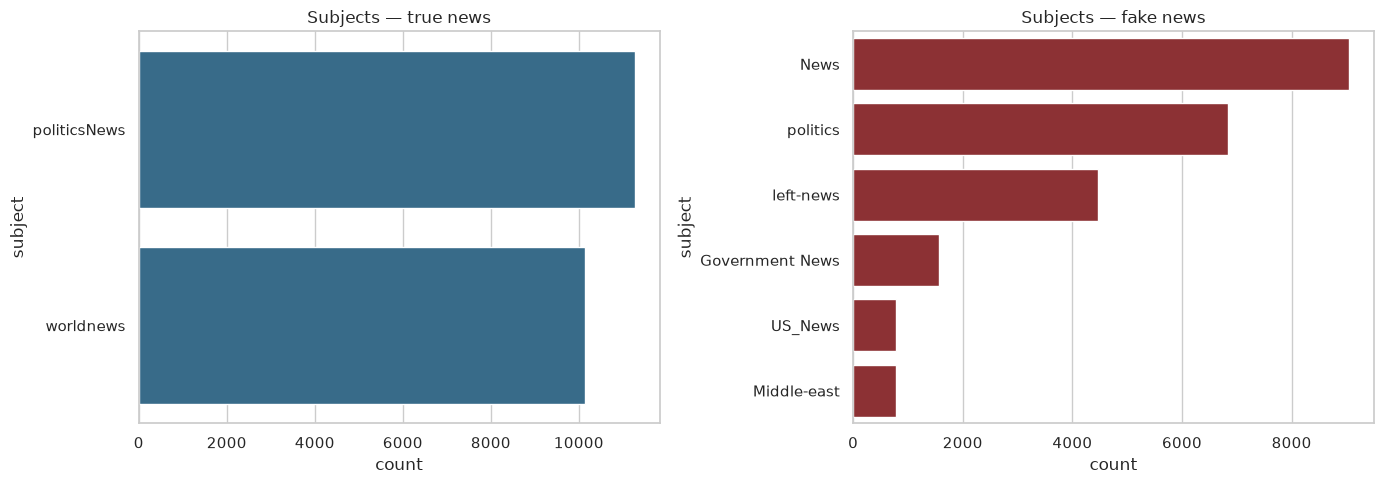

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(
    ax=axes[0],
    y="subject",
    data=df_true,
    order=df_true["subject"].value_counts().index,
    color="#2a6f97",
)
axes[0].set_title("Subjects — true news")
sns.countplot(
    ax=axes[1],
    y="subject",
    data=df_fake,
    order=df_fake["subject"].value_counts().index,
    color="#9b2226",
)
axes[1].set_title("Subjects — fake news")
plt.tight_layout()
plt.show()

### Word clouds for titles

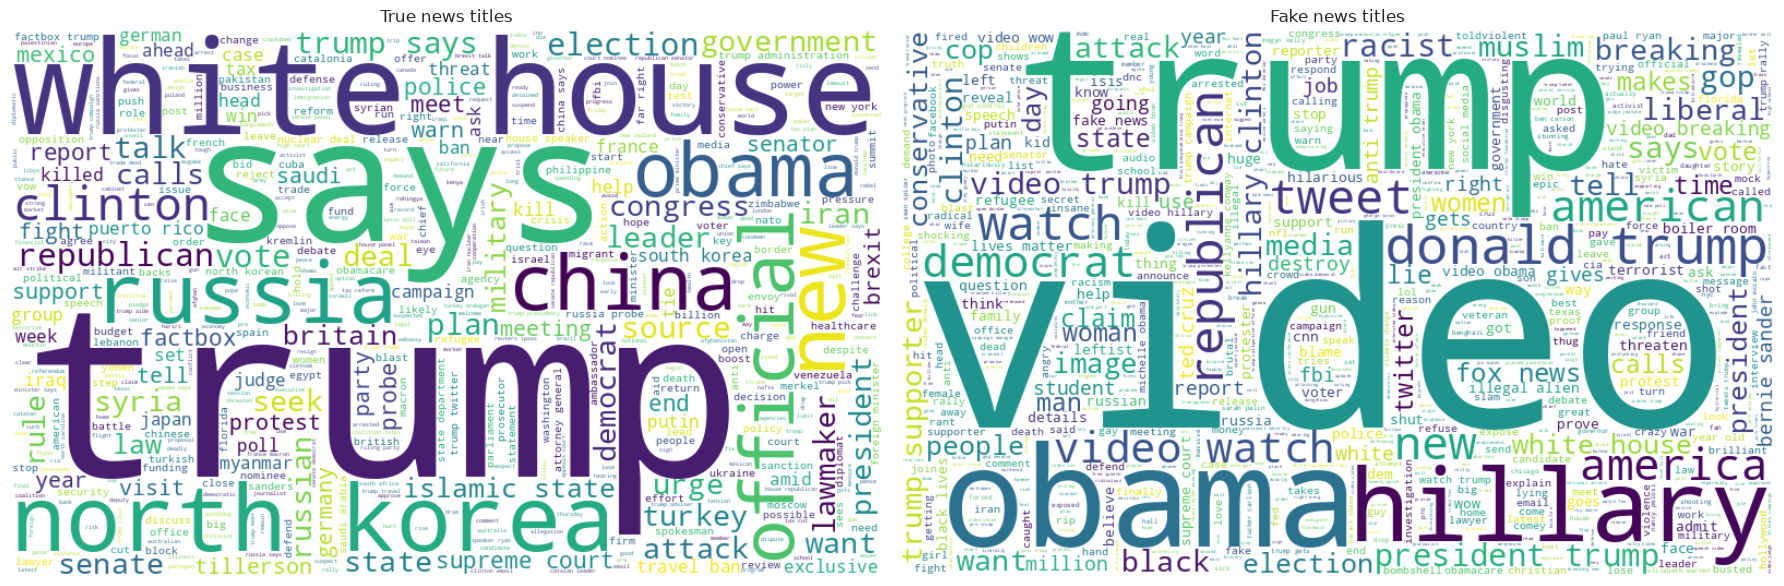

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
wc_true = WordCloud(
    max_words=2000, width=800, height=500, background_color="white"
).generate(" ".join(df_all.loc[df_all.label == 1, "processed_title"]))
wc_fake = WordCloud(
    max_words=2000, width=800, height=500, background_color="white"
).generate(" ".join(df_all.loc[df_all.label == 0, "processed_title"]))
axes[0].imshow(wc_true, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("True news titles")
axes[1].imshow(wc_fake, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Fake news titles")
plt.tight_layout()
plt.show()

**Observation:** True and fake titles share frequent tokens such as political names and
verbs like "says." Shared topical vocabulary alone is not enough to decide credibility;
the models below lean on broader distributional patterns in the article body.

### Character and word length distributions

In [7]:
def char_len_no_spaces(series):
    return series.fillna("").map(lambda x: len(x) - x.count(" "))


def word_len(series):
    return series.fillna("").map(lambda x: len(x.split()))


length_frames = {
    "Title characters (true)": char_len_no_spaces(df_all.loc[df_all.label == 1, "title"]),
    "Title characters (fake)": char_len_no_spaces(df_all.loc[df_all.label == 0, "title"]),
    "Text characters (true)": char_len_no_spaces(df_all.loc[df_all.label == 1, "text"]),
    "Text characters (fake)": char_len_no_spaces(df_all.loc[df_all.label == 0, "text"]),
    "Title words (true)": word_len(df_all.loc[df_all.label == 1, "title"]),
    "Title words (fake)": word_len(df_all.loc[df_all.label == 0, "title"]),
    "Text words (true)": word_len(df_all.loc[df_all.label == 1, "text"]),
    "Text words (fake)": word_len(df_all.loc[df_all.label == 0, "text"]),
    "Processed title words (true)": word_len(
        df_all.loc[df_all.label == 1, "processed_title"]
    ),
    "Processed title words (fake)": word_len(
        df_all.loc[df_all.label == 0, "processed_title"]
    ),
    "Processed text words (true)": word_len(
        df_all.loc[df_all.label == 1, "processed_text"]
    ),
    "Processed text words (fake)": word_len(
        df_all.loc[df_all.label == 0, "processed_text"]
    ),
}

for title, series in length_frames.items():
    fig = px.histogram(x=series, nbins=60, title=title)
    fig.update_layout(
        xaxis_title="Length",
        yaxis_title="Count",
        height=320,
        margin=dict(l=20, r=20, t=40, b=20),
    )
    fig.show()

**Observations (from the original analysis):**

- Fake titles tend to be slightly longer (more characters / words) than true titles —
  often more provocative framing.
- Body length distributions differ between classes; some fake articles are extremely short.
- Patterns remain after stopword removal.

These are **dataset-level style differences**, not proof of a general linguistic law of
"fakeness."

### Common bigrams

In [8]:
def top_bigrams(text_series, n=10):
    tokens = [tok for doc in text_series for tok in doc.split() if tok]
    counts = pd.Series(ngrams(tokens, 2)).value_counts().head(n)
    return counts.to_frame("count")


print("Top bigrams — true titles")
display(top_bigrams(df_all.loc[df_all.label == 1, "processed_title"]))
print("Top bigrams — fake titles")
display(top_bigrams(df_all.loc[df_all.label == 0, "processed_title"]))
print("Top bigrams — true text")
display(top_bigrams(df_all.loc[df_all.label == 1, "processed_text"]))
print("Top bigrams — fake text")
display(top_bigrams(df_all.loc[df_all.label == 0, "processed_text"]))

Top bigrams — true titles


,count
"(white, house)",790
"(north, korea)",720
"(trump, says)",364
"(islamic, state)",251
"(supreme, court)",235
"(puerto, rico)",178
"(south, korea)",160
"(says, trump)",159
"(travel, ban)",156
"(trump, administration)",148


Top bigrams — fake titles


,count
"(donald, trump)",805
"(video, watch)",509
"(president, trump)",504
"(video, trump)",460
"(hillary, clinton)",417
"(white, house)",348
"(fox, news)",314
"(trump, video)",311
"(video, breaking)",270
"(anti, trump)",261


Top bigrams — true text


,count
"(united, states)",12204
"(donald, trump)",10168
"(white, house)",8419
"(washington, reuters)",6679
"(president, donald)",5930
"(north, korea)",5659
"(new, york)",4740
"(prime, minister)",4163
"(said, statement)",3934
"(trump, said)",3586


Top bigrams — fake text


,count
"(donald, trump)",16395
"(featured, image)",8063
"(hillary, clinton)",7307
"(white, house)",6745
"(united, states)",6663
"(twitter, com)",6567
"(pic, twitter)",6232
"(new, york)",4359
"(president, obama)",4095
"(president, trump)",4049


## Train / test split

Models are trained on the **processed article body** (`processed_text`). An earlier note
in the coursework version said "titles only"; the executed pipeline used the body text,
and this cleaned notebook matches that actual experiment.

Split: 80% train / 20% test, `random_state=7`, **without replacement** (no train/test
overlap). The original Colab notebook used `sample(..., replace=True)`, which can leak
examples across splits and inflate scores — documented as a limitation rather than preserved.

In [9]:
sampled = df_all.sample(
    frac=1.0, random_state=RANDOM_STATE, replace=False
).reset_index(drop=True)
cut = int(sampled.shape[0] * (1 - TEST_SIZE))
train = sampled.iloc[:cut].copy()
test = sampled.iloc[cut:].copy()

# Replace raw title/text with processed versions (avoid duplicate column names).
train["title"] = train["processed_title"]
train["text"] = train["processed_text"]
test["title"] = test["processed_title"]
test["text"] = test["processed_text"]
train = train[["title", "text", "subject", "date", "label"]]
test = test[["title", "text", "subject", "date", "label"]]

print(f"Train size: {len(train)} | Test size: {len(test)}")
print(
    "Train fake/true: "
    f"{(train.label == 0).sum()} / {(train.label == 1).sum()} "
    f"({(train.label == 0).mean():.2%} / {(train.label == 1).mean():.2%})"
)
print(
    "Test fake/true: "
    f"{(test.label == 0).sum()} / {(test.label == 1).sum()} "
    f"({(test.label == 0).mean():.2%} / {(test.label == 1).mean():.2%})"
)

Train size: 35918 | Test size: 8980
Train fake/true: 18787 / 17131 (52.31% / 47.69%)
Test fake/true: 4694 / 4286 (52.27% / 47.73%)


## Vectorization

Three representations of the processed article body:

1. **CountVectorizer** — unigram + bigram bag-of-words counts (`min_df=2`)
2. **TfidfVectorizer** — unigram + bigram TF-IDF (`min_df=2`)
3. **Word2Vec** — embeddings averaged into a document vector (trained on the train split)

`min_df=2` is a small practicality change versus the original Colab run (which kept hapaxes
and produced multi-million-dimensional sparse matrices). Model choices and the rest of the
pipeline match the original study.

In [10]:
def document_vector(doc, w2v):
    """Average Word2Vec vectors for tokens present in the model vocabulary."""
    words = [w for w in str(doc).split() if w in w2v.wv]
    if not words:
        return np.zeros(w2v.vector_size, dtype=float)
    return np.mean(w2v.wv[words], axis=0)


# min_df=2 drops hapax unigrams/bigrams (tractable sparse matrices; same model family).
count_vec = CountVectorizer(ngram_range=(1, 2), lowercase=True, min_df=2)
X_train_count = count_vec.fit_transform(train["text"])
X_test_count = count_vec.transform(test["text"])

tfidf_vec = TfidfVectorizer(
    use_idf=True,
    ngram_range=(1, 2),
    smooth_idf=True,
    lowercase=True,
    min_df=2,
)
X_train_tfidf = tfidf_vec.fit_transform(train["text"])
X_test_tfidf = tfidf_vec.transform(test["text"])

sentences = [doc.split() for doc in train["text"]]
EMBEDDING_DIM = 100
w2v = Word2Vec(
    sentences=sentences,
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=1,
    workers=4,
)

X_train_w2v = np.vstack(
    train["text"].map(lambda d: document_vector(d, w2v)).to_numpy()
)
X_test_w2v = np.vstack(
    test["text"].map(lambda d: document_vector(d, w2v)).to_numpy()
)

y_train = train["label"].to_numpy()
y_test = test["label"].to_numpy()

print("Count features:", X_train_count.shape[1])
print("TF-IDF features:", X_train_tfidf.shape[1])
print("Word2Vec dim:", X_train_w2v.shape[1])

Count features: 1150177
TF-IDF features: 1150177
Word2Vec dim: 100


## Modeling helpers

Each run reports **accuracy**, **F1** (positive class = true news), and **ROC-AUC**.
Results are collected into a comparison table.

Note: the original notebook printed `roc_auc_score(...)` under the label "Accuracy."
Here the metrics are named correctly.

In [11]:
results = []


def evaluate_model(name, vectorizer_name, model, X_tr, X_te, y_tr=y_train, y_te=y_test):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_te)
    else:
        y_score = y_pred

    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_score)

    print(f"{name} + {vectorizer_name}")
    print(f"  Accuracy : {acc:.4f} ({acc * 100:.2f}%)")
    print(f"  F1       : {f1:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print()

    results.append(
        {
            "model": name,
            "vectorizer": vectorizer_name,
            "accuracy": acc,
            "f1": f1,
            "roc_auc": auc,
            "estimator": model,
            "y_pred": y_pred,
        }
    )
    return model, y_pred

### Logistic Regression

In [12]:
evaluate_model(
    "Logistic Regression",
    "Count",
    LogisticRegression(C=2.5, max_iter=1000),
    X_train_count,
    X_test_count,
)
evaluate_model(
    "Logistic Regression",
    "TF-IDF",
    LogisticRegression(C=2.5, max_iter=1000),
    X_train_tfidf,
    X_test_tfidf,
)
evaluate_model(
    "Logistic Regression",
    "Word2Vec",
    LogisticRegression(C=100, max_iter=1000),
    X_train_w2v,
    X_test_w2v,
)

Logistic Regression + Count
  Accuracy : 0.9952 (99.52%)
  F1       : 0.9950
  ROC-AUC  : 0.9996



Logistic Regression + TF-IDF
  Accuracy : 0.9855 (98.55%)
  F1       : 0.9849
  ROC-AUC  : 0.9985



Logistic Regression + Word2Vec
  Accuracy : 0.9663 (96.63%)
  F1       : 0.9647
  ROC-AUC  : 0.9944



(LogisticRegression(C=100, max_iter=1000),
 array([1, 1, 0, ..., 1, 0, 1], shape=(8980,)))

### Naive Bayes

MultinomialNB expects non-negative features. For Word2Vec embeddings, values are
min-max scaled to `[0, 1]` using statistics fit on the **training** split only.

In [13]:
evaluate_model(
    "Naive Bayes", "Count", MultinomialNB(alpha=0.1), X_train_count, X_test_count
)
evaluate_model(
    "Naive Bayes", "TF-IDF", MultinomialNB(alpha=0.1), X_train_tfidf, X_test_tfidf
)

scaler = MinMaxScaler()
X_train_w2v_nb = scaler.fit_transform(X_train_w2v)
X_test_w2v_nb = scaler.transform(X_test_w2v)
evaluate_model(
    "Naive Bayes",
    "Word2Vec",
    MultinomialNB(alpha=0.1),
    X_train_w2v_nb,
    X_test_w2v_nb,
)

Naive Bayes + Count
  Accuracy : 0.9698 (96.98%)
  F1       : 0.9687
  ROC-AUC  : 0.9844



Naive Bayes + TF-IDF
  Accuracy : 0.9598 (95.98%)
  F1       : 0.9583
  ROC-AUC  : 0.9915

Naive Bayes + Word2Vec
  Accuracy : 0.8822 (88.22%)
  F1       : 0.8684
  ROC-AUC  : 0.9631



(MultinomialNB(alpha=0.1), array([1, 1, 0, ..., 1, 0, 0], shape=(8980,)))

### Linear SVM

The original notebook used `SVC(kernel="linear")`. This version uses `LinearSVC`,
the standard scalable linear SVM formulation (liblinear), which is much faster on
high-dimensional sparse text features and is the intended model family.

In [14]:
evaluate_model(
    "Linear SVM",
    "Count",
    LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=5000),
    X_train_count,
    X_test_count,
)
evaluate_model(
    "Linear SVM",
    "TF-IDF",
    LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=5000),
    X_train_tfidf,
    X_test_tfidf,
)
evaluate_model(
    "Linear SVM",
    "Word2Vec",
    LinearSVC(C=1.0, random_state=RANDOM_STATE, max_iter=5000),
    X_train_w2v,
    X_test_w2v,
)

/home/ubuntu/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Linear SVM + Count
  Accuracy : 0.9963 (99.63%)
  F1       : 0.9962
  ROC-AUC  : 0.9995



Linear SVM + TF-IDF
  Accuracy : 0.9931 (99.31%)
  F1       : 0.9928
  ROC-AUC  : 0.9995



Linear SVM + Word2Vec
  Accuracy : 0.9665 (96.65%)
  F1       : 0.9650
  ROC-AUC  : 0.9942



(LinearSVC(random_state=7), array([1, 1, 0, ..., 1, 0, 1], shape=(8980,)))

### Random Forest

In [15]:
evaluate_model(
    "Random Forest",
    "Count",
    RandomForestClassifier(
        n_estimators=10, criterion="entropy", random_state=0, n_jobs=-1
    ),
    X_train_count,
    X_test_count,
)
evaluate_model(
    "Random Forest",
    "TF-IDF",
    RandomForestClassifier(
        n_estimators=10, criterion="entropy", random_state=0, n_jobs=-1
    ),
    X_train_tfidf,
    X_test_tfidf,
)
evaluate_model(
    "Random Forest",
    "Word2Vec",
    RandomForestClassifier(
        n_estimators=10, criterion="entropy", random_state=0, n_jobs=-1
    ),
    X_train_w2v,
    X_test_w2v,
)

Random Forest + Count
  Accuracy : 0.9666 (96.66%)
  F1       : 0.9646
  ROC-AUC  : 0.9944



Random Forest + TF-IDF
  Accuracy : 0.9608 (96.08%)
  F1       : 0.9583
  ROC-AUC  : 0.9937



Random Forest + Word2Vec
  Accuracy : 0.9569 (95.69%)
  F1       : 0.9542
  ROC-AUC  : 0.9910



(RandomForestClassifier(criterion='entropy', n_estimators=10, n_jobs=-1,
                        random_state=0),
 array([1, 1, 0, ..., 1, 0, 1], shape=(8980,)))

## Beat the benchmark

Following the original study, Random Forest + TF-IDF is re-run with a larger ensemble
(`n_estimators=150`).

In [16]:
SEED = 4353
rf_improved, y_pred_rf = evaluate_model(
    "Random Forest (improved)",
    "TF-IDF",
    RandomForestClassifier(n_estimators=150, max_depth=None, random_state=SEED),
    X_train_tfidf,
    X_test_tfidf,
)

print(classification_report(y_test, y_pred_rf, digits=4))
print("Confusion matrix [ [TN FP], [FN TP] ]:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest (improved) + TF-IDF
  Accuracy : 0.9869 (98.69%)
  F1       : 0.9863
  ROC-AUC  : 0.9991

              precision    recall  f1-score   support

           0     0.9933    0.9815    0.9874      4694
           1     0.9800    0.9928    0.9863      4286

    accuracy                         0.9869      8980
   macro avg     0.9866    0.9871    0.9868      8980
weighted avg     0.9869    0.9869    0.9869      8980

Confusion matrix [ [TN FP], [FN TP] ]:
[[4607   87]
 [  31 4255]]


## Model comparison

,model,vectorizer,accuracy,f1,roc_auc
0,Linear SVM,Count,0.9963,0.9962,0.9995
1,Logistic Regression,Count,0.9952,0.9950,0.9996
2,Linear SVM,TF-IDF,0.9931,0.9928,0.9995
3,Random Forest (improved),TF-IDF,0.9869,0.9863,0.9991
4,Logistic Regression,TF-IDF,0.9855,0.9849,0.9985
5,Naive Bayes,Count,0.9698,0.9687,0.9844
6,Random Forest,Count,0.9666,0.9646,0.9944
7,Linear SVM,Word2Vec,0.9665,0.9650,0.9942
8,Logistic Regression,Word2Vec,0.9663,0.9647,0.9944
9,Random Forest,TF-IDF,0.9608,0.9583,0.9937


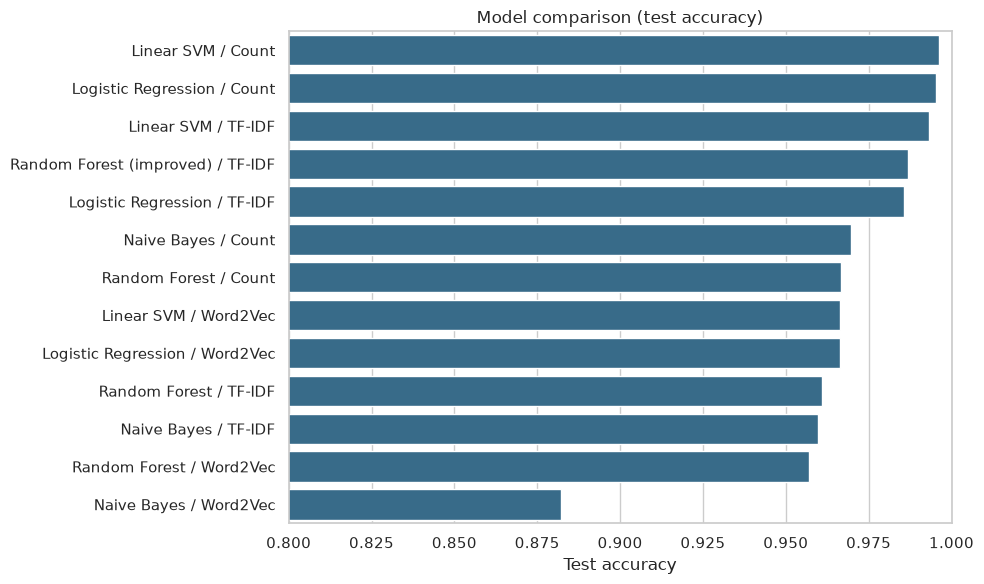

Wrote results_summary.csv


In [17]:
results_df = pd.DataFrame(
    [
        {k: v for k, v in row.items() if k not in {"estimator", "y_pred"}}
        for row in results
    ]
)
results_df = results_df.sort_values(
    ["accuracy", "f1"], ascending=False
).reset_index(drop=True)
display(
    results_df.style.format(
        {"accuracy": "{:.4f}", "f1": "{:.4f}", "roc_auc": "{:.4f}"}
    )
)

plot_df = results_df.copy()
plot_df["label"] = plot_df["model"] + " / " + plot_df["vectorizer"]
plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, y="label", x="accuracy", color="#2a6f97")
plt.xlabel("Test accuracy")
plt.ylabel("")
plt.title("Model comparison (test accuracy)")
plt.xlim(0.8, 1.0)
plt.tight_layout()
plt.show()

results_df.to_csv("results_summary.csv", index=False)
print("Wrote results_summary.csv")

## Error analysis

Inspect mistakes from the strongest sparse linear model. High scores on this dataset are
common because **true** and **fake** articles come from stylistically different sources
(e.g., Reuters datelines vs. blog/propaganda style), so errors are more informative than
the headline accuracy number.

Analyzing errors for: Linear SVM + Count
Accuracy=0.9963 | F1=0.9962


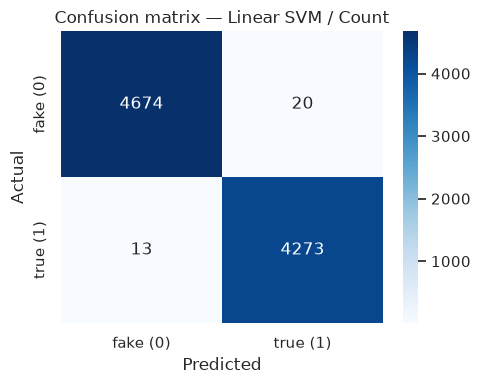

Misclassified articles: 33 / 8980

False positives (fake → predicted true):


,title,subject,label,predicted
30,breaking appeals court deals obama executive amnesty huge blow,left-news,0,1
280,wow washington post publishes realnews story president trump trump leadership gains isis dramatically accelerated,left-news,0,1
467,breaking massive cyber attack federal employee info,Government News,0,1
1076,new poll clinton beating trump points largest lead,News,0,1
1537,ruling obama head spin fed judge says telling illegals papers discriminatory,politics,0,1


False negatives (true → predicted fake):


,title,subject,label,predicted
911,clinton defends wife super predator comment protesters,politicsNews,1,0
2199,obama drinks coconut water cool laos,politicsNews,1,0
3323,art deal putin needs trump,politicsNews,1,0
3822,hacked emails clinton aides surprised email revelations,politicsNews,1,0
4050,american fanfare canada raises eyebrows home,politicsNews,1,0


In [18]:
main_results = [r for r in results if r["model"] != "Random Forest (improved)"]
best = max(main_results, key=lambda r: r["accuracy"])
print(f"Analyzing errors for: {best['model']} + {best['vectorizer']}")
print(f"Accuracy={best['accuracy']:.4f} | F1={best['f1']:.4f}")

y_pred_best = best["y_pred"]
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["fake (0)", "true (1)"],
    yticklabels=["fake (0)", "true (1)"],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {best['model']} / {best['vectorizer']}")
plt.tight_layout()
plt.show()

error_view = test.copy().reset_index(drop=True)
error_view["predicted"] = y_pred_best
errors = error_view[error_view["label"] != error_view["predicted"]].copy()
print(f"Misclassified articles: {len(errors)} / {len(error_view)}")

false_positives = errors[errors["predicted"] == 1].head(5)
false_negatives = errors[errors["predicted"] == 0].head(5)

print("\nFalse positives (fake → predicted true):")
display(false_positives[["title", "subject", "label", "predicted"]])
print("False negatives (true → predicted fake):")
display(false_negatives[["title", "subject", "label", "predicted"]])

## Limitations

1. **Dataset artifact risk.** "True" articles are largely Reuters wire copy; "fake"
   articles come from very different outlets. Models can latch onto **source/style cues**
   (datelines, diction) rather than factual veracity.
2. **Not a real-world detector.** Labels are corpus-defined, not adjudicated claim-level
   truth for arbitrary web text.
3. **Classical features only.** No transformers, production calibration, or temporal /
   domain-shift evaluation.
4. **Word2Vec setup is basic.** Embeddings are trained only on this corpus and averaged;
   that underperforms sparse lexical models here.
5. **Original coursework quirks (fixed here).** Google Drive paths, `replace=True`
   sampling, outdated Gensim APIs, TF-IDF Random Forest predicting with the Count matrix,
   and metric mislabeling (`roc_auc_score` printed as "Accuracy").

## Relation to retrieval / RAG

This project is **supervised text classification**: map a document to a label with
labeled training data.

Retrieval and RAG are different problems: index a corpus, fetch relevant passages for a
query, optionally condition a generator on those passages. Shared foundations include
tokenization, vector representations, and evaluation discipline — but classification
accuracy on ISOT is **not** evidence of retrieval quality. Treat this notebook as early
NLP/ML groundwork adjacent to, not equivalent to, retrieval engineering.

## How to re-run

```bash
python scripts/download_data.py
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
jupyter notebook fake_news_classification.ipynb
```